# Detectarea Zilelor cu Aer Periculos pentru Grupurile Sensibile — Clasificare Binară

## 1. Definirea Problemei

### Problema abordată
Acest proiect abordează o **problemă de clasificare binară pe un set de date sever dezechilibrat**: detectarea zilelor în care calitatea aerului este periculoasă pentru grupurile sensibile (copii, vârstnici, persoane cu afecțiuni respiratorii) din Germania, pe baza poluanților atmosferici și a factorilor de mediu.

### Variabila țintă
- **`Is_Unhealthy`** — variabilă binară creată din `AQI_Bucket`:
  - **0 — Aer Acceptabil** (clase „Good" + „Moderate") — clasa majoritară (~99.5%)
  - **1 — Aer Periculos** (clasa „Unhealthy for Sensitive Groups") — clasa minoritară (~0.5%)

### Provocarea dezechilibrului
Cu doar **50 de observații** din clasa 1 (din 10,512 total), setul de date este **extrem de dezechilibrat**. Un model care prezice mereu 0 obține ~99.5% Accuracy — dar este complet inutil.

**Accuracy este o metrică înșelătoare** în acest context. Ne vom concentra pe:
- **Recall** (clasa 1) — câte zile periculoase detectăm efectiv?
- **F1-Score** (clasa 1) — echilibrul între Precision și Recall
- **ROC-AUC** — capacitatea modelului de a separa clasele

### Coloanele eliminate (prevenirea data leakage)
- **`AQI`** și **`AQI_Bucket`** — acestea sunt derivate direct din target, deci le eliminăm


## 2. Importarea Bibliotecilor

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from interpret.glassbox import ExplainableBoostingClassifier

from skopt import BayesSearchCV
from skopt.space import Integer, Real, Categorical

import shap

## 3. Încărcarea datelor și crearea target-ului


In [2]:
df = pd.read_csv('germany_air_quality_2014_2025.csv')
print(f"Dimensiune inițială: {df.shape}")
print(f"\nDistribuția AQI_Bucket:")
print(df['AQI_Bucket'].value_counts())

df['Is_Unhealthy'] = (df['AQI_Bucket'] == 'Unhealthy for Sensitive Groups').astype(int)

print(f"\nDistribuția Is_Unhealthy:")
print(df['Is_Unhealthy'].value_counts())
print(f"\nProporție clasa 1: {df['Is_Unhealthy'].mean():.4f} ({df['Is_Unhealthy'].sum()} din {len(df)})")

df.drop(['AQI', 'AQI_Bucket'], axis=1, inplace=True)
print(f"\nDimensiune după eliminare: {df.shape}")
df.head()


Dimensiune inițială: (10512, 23)

Distribuția AQI_Bucket:
AQI_Bucket
Moderate                          5799
Good                              4663
Unhealthy for Sensitive Groups      50
Name: count, dtype: int64

Distribuția Is_Unhealthy:
Is_Unhealthy
0    10462
1       50
Name: count, dtype: int64

Proporție clasa 1: 0.0048 (50 din 10512)

Dimensiune după eliminare: (10512, 22)


,State,City,Date,PM2.5 (ug/m3),PM10 (ug/m3),NO (ug/m3),NO2 (ug/m3),NOx (ppb),NH3 (ug/m3),CO (mg/m3),...,Benzene (ug/m3),Toluene (ug/m3),Xylene (ug/m3),Wind_Speed (km/h),Humidity (%),Deforestation_Rate_%,Industry_Growth_%,CO2_Emission_MT,Population_Density_per_SqKm,Is_Unhealthy
0,North Rhine-Westphalia,Cologne,2014-01-01,25.973713,37.359380,15.688356,20.833653,19.356665,8.132103,0.665430,...,0.739620,1.826089,0.632729,16.161422,51.600682,0.512537,4.446246,3.791483,1334.324681,0
1,North Rhine-Westphalia,Cologne,2014-02-01,20.893886,34.177014,14.453767,27.245428,22.100573,9.590623,0.219019,...,0.275951,0.697044,0.294310,18.955132,100.000000,0.621256,5.042207,3.703239,1339.337177,0
2,North Rhine-Westphalia,Cologne,2014-03-01,27.181508,52.224166,12.841772,30.714188,23.084659,9.426700,0.783820,...,0.496332,1.223330,0.636173,18.361722,66.482247,0.120008,1.970017,0.100000,1268.486184,0
3,North Rhine-Westphalia,Cologne,2014-04-01,34.184239,57.992655,11.174462,41.160533,27.737547,7.042489,0.720767,...,0.617566,1.689481,0.839835,12.222137,71.635149,0.738092,1.068437,4.895885,1295.982837,0
4,North Rhine-Westphalia,Cologne,2014-05-01,20.126773,35.766775,9.748523,28.077726,20.047912,9.547772,0.582115,...,0.252621,0.529286,0.320352,14.435880,76.862854,0.153745,5.573603,5.952436,1372.756614,0


## 4. Analiza Exploratorie a Datelor (EDA)

### 4.1 Vizualizarea dezechilibrului de clase


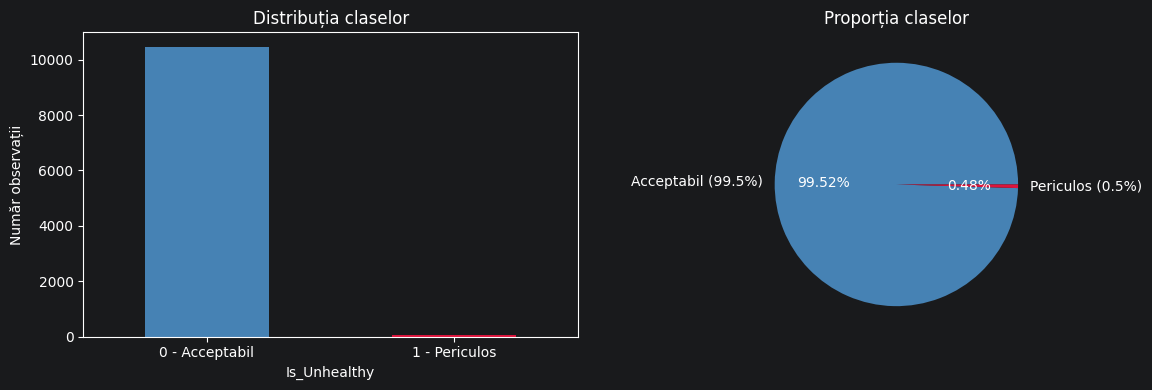

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['Is_Unhealthy'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'crimson'])
axes[0].set_title('Distribuția claselor')
axes[0].set_xticklabels(['0 - Acceptabil', '1 - Periculos'], rotation=0)
axes[0].set_ylabel('Număr observații')

df['Is_Unhealthy'].value_counts().plot(kind='pie', ax=axes[1],
    labels=['Acceptabil (99.5%)', 'Periculos (0.5%)'],
    colors=['steelblue', 'crimson'], autopct='%1.2f%%')
axes[1].set_ylabel('')
axes[1].set_title('Proporția claselor')

plt.tight_layout()
plt.show()


### 4.2 Distribuția poluanților — comparație între clase

Analizăm dacă zilele periculoase au valori mai mari ale poluanților principali.


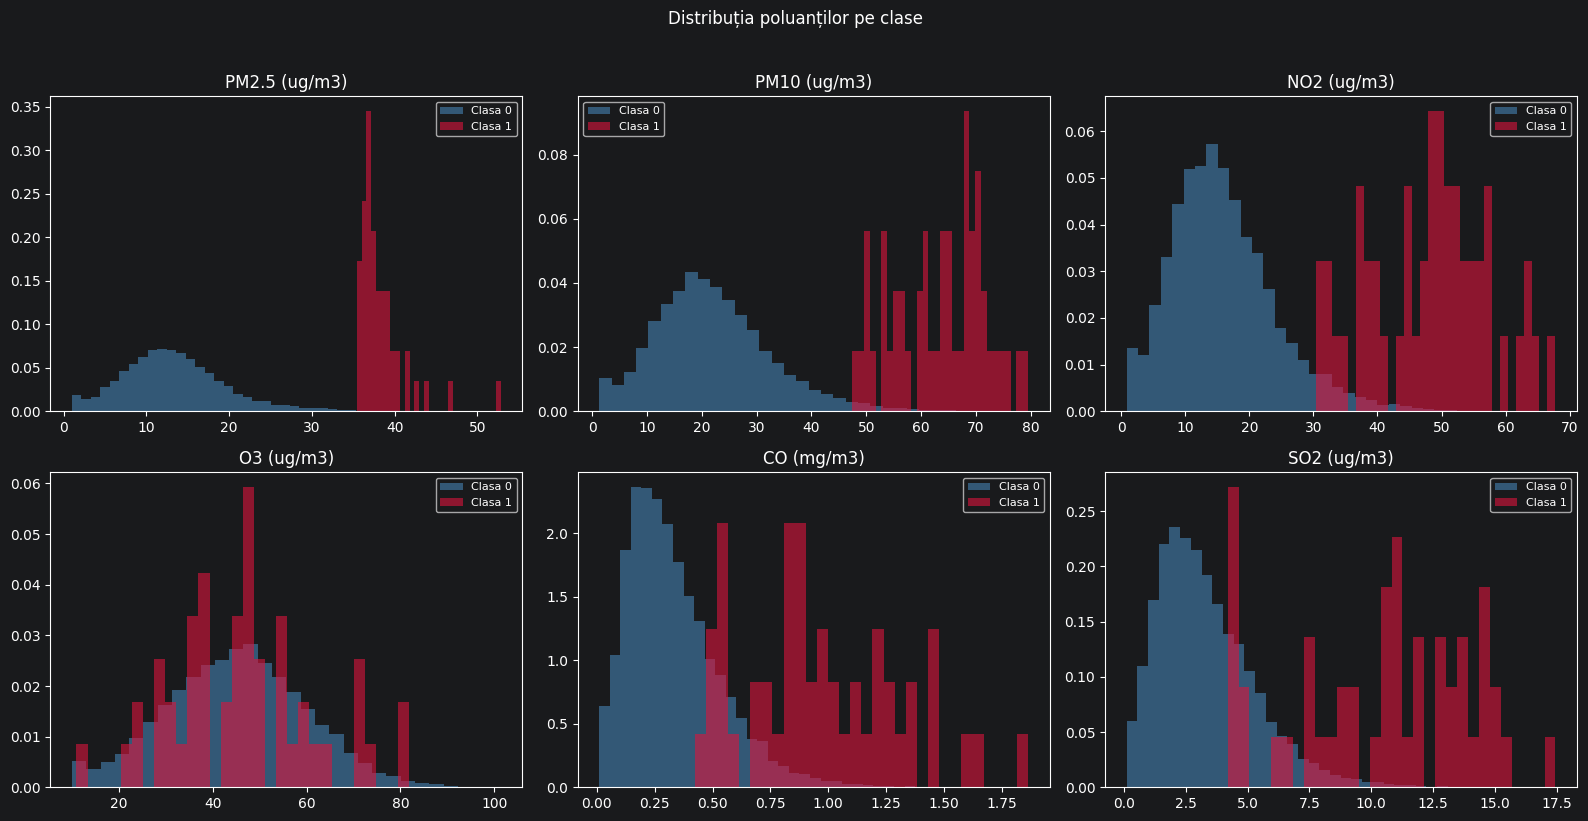

In [4]:
pollutants = ['PM2.5 (ug/m3)', 'PM10 (ug/m3)', 'NO2 (ug/m3)', 'O3 (ug/m3)',
              'CO (mg/m3)', 'SO2 (ug/m3)']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for i, col in enumerate(pollutants):
    ax = axes[i // 3][i % 3]
    for label, color in [(0, 'steelblue'), (1, 'crimson')]:
        subset = df[df['Is_Unhealthy'] == label][col]
        ax.hist(subset, bins=30, alpha=0.6, color=color,
                label=f'Clasa {label}', density=True)
    ax.set_title(col)
    ax.legend(fontsize=8)

plt.suptitle('Distribuția poluanților pe clase', y=1.02)
plt.tight_layout()
plt.show()


### 4.3 Statistici comparative pe clase

Comparăm media caracteristicilor pentru cele două clase.


In [5]:
num_cols = df.select_dtypes(include=[np.number]).columns.drop('Is_Unhealthy')
comparison = df.groupby('Is_Unhealthy')[num_cols].mean().T
comparison.columns = ['Acceptabil (0)', 'Periculos (1)']
comparison['Raport 1/0'] = comparison['Periculos (1)'] / comparison['Acceptabil (0)']
comparison.sort_values('Raport 1/0', ascending=False)


,Acceptabil (0),Periculos (1),Raport 1/0
SO2 (ug/m3),3.312871,10.421865,3.145871
NO2 (ug/m3),15.878533,48.142110,3.031899
NOx (ppb),11.917030,35.597459,2.987108
CO (mg/m3),0.331477,0.964672,2.910218
Toluene (ug/m3),0.595631,1.727919,2.900989
PM2.5 (ug/m3),13.252156,38.312614,2.891048
PM10 (ug/m3),21.946691,63.343841,2.886259
NO (ug/m3),6.606429,19.022907,2.879454
Benzene (ug/m3),0.264083,0.746109,2.825288
Xylene (ug/m3),0.276118,0.771502,2.794106


### 4.4 Matricea de corelație


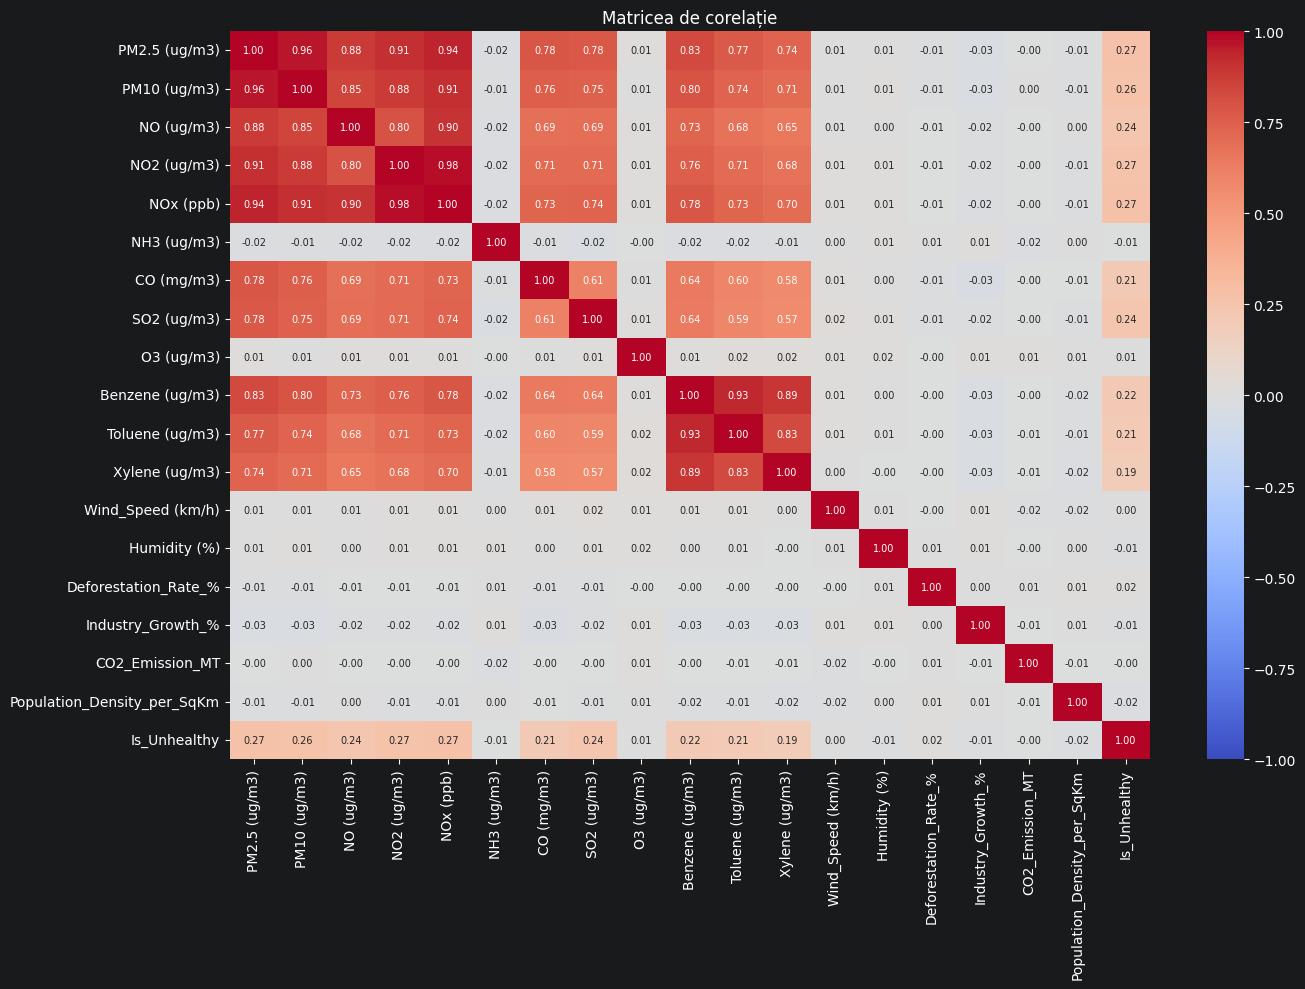

In [6]:
plt.figure(figsize=(14, 10))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            annot_kws={'size': 7})
plt.title('Matricea de corelație')
plt.tight_layout()
plt.show()


### 4.5 Box-plot-uri: poluanți cheie per clasă


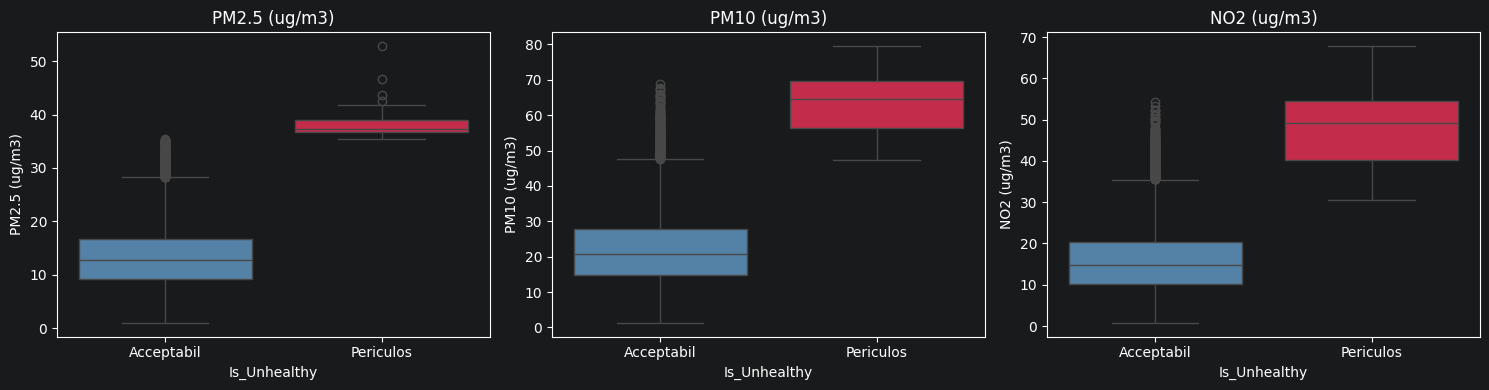

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, feat in enumerate(['PM2.5 (ug/m3)', 'PM10 (ug/m3)', 'NO2 (ug/m3)']):
    sns.boxplot(data=df, x='Is_Unhealthy', y=feat, ax=axes[i],
                palette=['steelblue', 'crimson'])
    axes[i].set_title(feat)
    axes[i].set_xticklabels(['Acceptabil', 'Periculos'])
plt.tight_layout()
plt.show()


## 5. Pregătirea datelor

Vom:
- procesa coloana `Date` (extragem anul și luna);
- codifica variabilele categorice (`State`, `City`) cu `LabelEncoder`;
- separa datele în train (75%) și test (25%) cu **stratificare** (esențial la dezechilibru);
- aplica `StandardScaler` pentru modelele sensibile la scară.


In [8]:
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df.drop('Date', axis=1, inplace=True)

le_state = LabelEncoder()
le_city = LabelEncoder()
df['State'] = le_state.fit_transform(df['State'])
df['City'] = le_city.fit_transform(df['City'])

X = df.drop('Is_Unhealthy', axis=1)
y = df['Is_Unhealthy']

print(f"Features: {X.shape[1]} coloane")
print(f"Distribuție target: {dict(y.value_counts())}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train),
                           columns=X_train.columns, index=X_train.index)
X_test_sc = pd.DataFrame(scaler.transform(X_test),
                          columns=X_test.columns, index=X_test.index)

print(f"\nTrain: {X_train.shape} | Test: {X_test.shape}")
print(f"Train clasa 1: {y_train.sum()} | Test clasa 1: {y_test.sum()}")


Features: 22 coloane
Distribuție target: {0: np.int64(10462), 1: np.int64(50)}

Train: (7884, 22) | Test: (2628, 22)
Train clasa 1: 38 | Test clasa 1: 12


## 6. Antrenarea și compararea modelelor de bază

Antrenăm 9 modele cu setările **implicite** (fără ajustări pentru dezechilibru — aceasta este linia de bază).

Modelele sensibile la scară (SVM, KNN, Logistic Regression) primesc datele scalate.

Ne concentrăm pe **Recall** și **F1** pentru clasa 1 — câte zile periculoase detectăm?


In [9]:
models = {
    'Naive Bayes': GaussianNB(),
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'KNN': KNeighborsClassifier(),
    'XGBoost': XGBClassifier(random_state=42, verbosity=0,
                             eval_metric='logloss', use_label_encoder=False),
    'CatBoost': CatBoostClassifier(random_state=42, verbose=0,
                                   allow_writing_files=False),
    'Explainable Boosting': ExplainableBoostingClassifier(random_state=42),
}

scaled_models = {'SVM', 'KNN', 'Logistic Regression'}

results = []

for name, model in models.items():
    if name in scaled_models:
        Xtr, Xte = X_train_sc, X_test_sc
    else:
        Xtr, Xte = X_train, X_test

    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    y_proba = model.predict_proba(Xte)[:, 1] if hasattr(model, 'predict_proba') else None

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else None

    results.append({
        'Model': name, 'Accuracy': acc, 'Precision': prec,
        'Recall (cls 1)': rec, 'F1 (cls 1)': f1, 'ROC-AUC': auc
    })
    auc_str = f"{auc:.4f}" if auc is not None else "N/A"
    print(f"{name:25s} | Acc={acc:.4f} | Recall={rec:.4f} | F1={f1:.4f} | AUC={auc_str}")

print("\nToate cele 9 modele au fost antrenate.")


Naive Bayes               | Acc=0.9779 | Recall=1.0000 | F1=0.2927 | AUC=0.9975
Logistic Regression       | Acc=0.9996 | Recall=1.0000 | F1=0.9600 | AUC=0.9998
Decision Tree             | Acc=1.0000 | Recall=1.0000 | F1=1.0000 | AUC=1.0000
Random Forest             | Acc=1.0000 | Recall=1.0000 | F1=1.0000 | AUC=1.0000
SVM                       | Acc=0.9973 | Recall=0.5000 | F1=0.6316 | AUC=0.9991
KNN                       | Acc=0.9970 | Recall=0.4167 | F1=0.5556 | AUC=0.9569
XGBoost                   | Acc=0.9985 | Recall=1.0000 | F1=0.8571 | AUC=1.0000
CatBoost                  | Acc=0.9996 | Recall=1.0000 | F1=0.9600 | AUC=1.0000
Explainable Boosting      | Acc=0.9996 | Recall=1.0000 | F1=0.9600 | AUC=1.0000

Toate cele 9 modele au fost antrenate.


### 6.1 Tabel comparativ

Sortăm modelele după **Recall (clasa 1)** — prioritatea este detectarea zilelor periculoase.

> **Observație importantă**: Modelele cu Recall=0 nu detectează nicio zi periculoasă, deși au Accuracy ~99.5%. Acest lucru demonstrează de ce Accuracy este înșelătoare la seturi dezechilibrate.


In [10]:
results_df = pd.DataFrame(results).sort_values('Recall (cls 1)', ascending=False).reset_index(drop=True)
results_df.index = results_df.index + 1
results_df

,Model,Accuracy,Precision,Recall (cls 1),F1 (cls 1),ROC-AUC
1,Naive Bayes,0.977930,0.171429,1.000000,0.292683,0.997515
2,Logistic Regression,0.999619,0.923077,1.000000,0.960000,0.999841
3,Decision Tree,1.000000,1.000000,1.000000,1.000000,1.000000
4,Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000
5,XGBoost,0.998478,0.750000,1.000000,0.857143,1.000000
6,Explainable Boosting,0.999619,0.923077,1.000000,0.960000,1.000000
7,CatBoost,0.999619,0.923077,1.000000,0.960000,1.000000
8,SVM,0.997336,0.857143,0.500000,0.631579,0.999076
9,KNN,0.996956,0.833333,0.416667,0.555556,0.956948


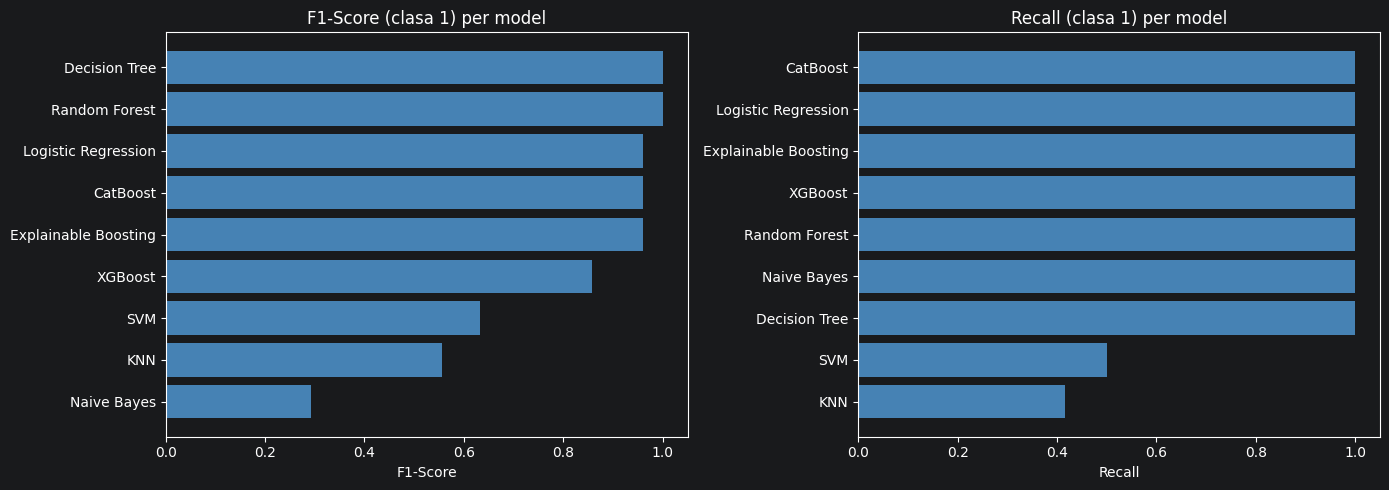

Top 5 modele selectate pentru tuning: ['Naive Bayes', 'Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost']


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results_sorted = results_df.sort_values('F1 (cls 1)', ascending=True)
colors = ['crimson' if v == 0 else 'steelblue' for v in results_sorted['F1 (cls 1)']]
axes[0].barh(results_sorted['Model'], results_sorted['F1 (cls 1)'], color=colors)
axes[0].set_title('F1-Score (clasa 1) per model')
axes[0].set_xlabel('F1-Score')

results_sorted2 = results_df.sort_values('Recall (cls 1)', ascending=True)
colors2 = ['crimson' if v == 0 else 'steelblue' for v in results_sorted2['Recall (cls 1)']]
axes[1].barh(results_sorted2['Model'], results_sorted2['Recall (cls 1)'], color=colors2)
axes[1].set_title('Recall (clasa 1) per model')
axes[1].set_xlabel('Recall')

plt.tight_layout()
plt.show()

top5_names = results_df.head(5)['Model'].tolist()
print("Top 5 modele selectate pentru tuning:", top5_names)

### 6.2 Matricea de confuzie — cel mai bun model de bază


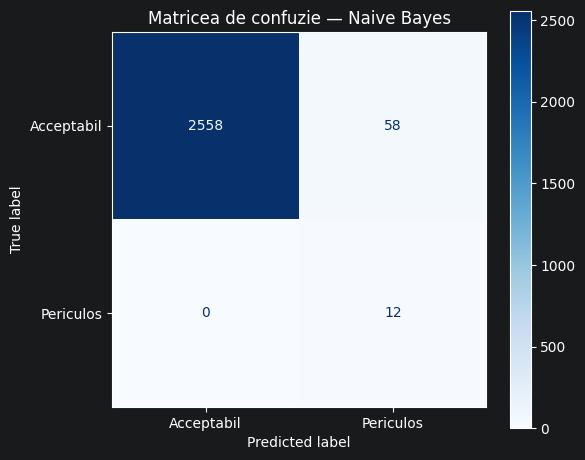

In [12]:
best_base = top5_names[0]
if best_base in scaled_models:
    y_pred_best = models[best_base].predict(X_test_sc)
else:
    y_pred_best = models[best_base].predict(X_test)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best,
    display_labels=['Acceptabil', 'Periculos'],
    ax=ax, cmap='Blues'
)
ax.set_title(f'Matricea de confuzie — {best_base}')
plt.tight_layout()
plt.show()

## 7. Optimizarea hiperparametrilor

### Strategie anti-dezechilibru
Pentru algoritmii care suportă, ajustăm parametrii de **class imbalance**:
- `scale_pos_weight` (XGBoost) — raportul clase neg/poz (~210)
- `class_weight='balanced'` (Random Forest, Logistic Regression, SVM, Decision Tree)
- `auto_class_weights='Balanced'` (CatBoost)

Scopul: **forțăm modelele să acorde atenție clasei minoritare (1 — Aer Periculos)**.

Cross-validation: 5-fold, scoring: `f1` (clasa 1).


In [14]:
imbalance_ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Raport dezechilibru (neg/poz): {imbalance_ratio:.1f}")

param_grids = {
    'Naive Bayes': {
        'method': 'grid',
        'params': {
            'var_smoothing': [1e-12, 1e-10, 1e-9, 1e-8, 1e-7, 1e-5, 1e-3],
        }
    },
    'Logistic Regression': {
        'method': 'grid',
        'params': {
            'C': [0.01, 0.1, 1, 10, 100],
            'class_weight': ['balanced'],
            'solver': ['lbfgs', 'saga'],
        }
    },
    'Decision Tree': {
        'method': 'grid',
        'params': {
            'max_depth': [3, 5, 10, 15, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 5],
            'class_weight': ['balanced'],
        }
    },
    'Random Forest': {
        'method': 'bayes',
        'params': {
            'n_estimators': Integer(50, 300),
            'max_depth': Integer(3, 20),
            'min_samples_split': Integer(2, 15),
            'class_weight': Categorical(['balanced', 'balanced_subsample']),
        },
        'n_iter': 25
    },
    'SVM': {
        'method': 'bayes',
        'params': {
            'C': Real(0.1, 100, prior='log-uniform'),
            'kernel': Categorical(['rbf', 'poly']),
            'gamma': Categorical(['scale', 'auto']),
            'class_weight': Categorical(['balanced']),
        },
        'n_iter': 20
    },
    'KNN': {
        'method': 'grid',
        'params': {
            'n_neighbors': [3, 5, 7, 11, 15],
            'weights': ['uniform', 'distance'],
            'metric': ['euclidean', 'manhattan'],
        }
    },
    'XGBoost': {
        'method': 'bayes',
        'params': {
            'n_estimators': Integer(50, 300),
            'max_depth': Integer(3, 10),
            'learning_rate': Real(0.01, 0.3, prior='log-uniform'),
            'scale_pos_weight': Real(50, 250),
            'subsample': Real(0.6, 1.0),
        },
        'n_iter': 30
    },
    'CatBoost': {
        'method': 'bayes',
        'params': {
            'iterations': Integer(100, 500),
            'depth': Integer(3, 8),
            'learning_rate': Real(0.01, 0.3, prior='log-uniform'),
            'auto_class_weights': Categorical(['Balanced', 'SqrtBalanced']),
        },
        'n_iter': 20
    },
    'Explainable Boosting': {
        'method': 'grid',
        'params': {
            'max_bins': [128, 256],
            'max_rounds': [5000, 10000],
            'learning_rate': [0.01, 0.02],
            'min_samples_leaf': [2, 5],
        }
    },
}


Raport dezechilibru (neg/poz): 206.5


In [15]:
tuned_results = []
best_models = {}

for model_name in top5_names:
    print(f"\n{'='*50}")
    print(f"Tuning: {model_name}")

    if model_name in scaled_models:
        Xtr, Xte = X_train_sc, X_test_sc
    else:
        Xtr, Xte = X_train, X_test

    base_models_init = {
        'Naive Bayes': GaussianNB(),
        'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
        'Decision Tree': DecisionTreeClassifier(random_state=42),
        'Random Forest': RandomForestClassifier(random_state=42),
        'SVM': SVC(probability=True, random_state=42),
        'KNN': KNeighborsClassifier(),
        'XGBoost': XGBClassifier(random_state=42, verbosity=0,
                                 eval_metric='logloss', use_label_encoder=False),
        'CatBoost': CatBoostClassifier(random_state=42, verbose=0,
                                       allow_writing_files=False),
        'Explainable Boosting': ExplainableBoostingClassifier(random_state=42),
    }

    grid_info = param_grids[model_name]
    method = grid_info['method']
    params = grid_info['params']
    base_model = base_models_init[model_name]

    if method == 'grid':
        search = GridSearchCV(
            estimator=base_model, param_grid=params,
            cv=5, scoring='f1', n_jobs=-1, verbose=0
        )
    else:
        search = BayesSearchCV(
            estimator=base_model, search_spaces=params,
            n_iter=grid_info.get('n_iter', 20),
            cv=5, scoring='f1', n_jobs=-1,
            verbose=0, random_state=42
        )

    search.fit(Xtr, y_train)
    best_model = search.best_estimator_
    best_models[model_name] = best_model

    y_pred = best_model.predict(Xte)
    y_proba = best_model.predict_proba(Xte)[:, 1] if hasattr(best_model, 'predict_proba') else None

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else None

    tuned_results.append({
        'Model': model_name, 'Method': method.upper(),
        'Accuracy': acc, 'Precision': prec, 'Recall (cls 1)': rec,
        'F1 (cls 1)': f1, 'ROC-AUC': auc, 'Best Params': search.best_params_,
    })

    auc_str = f"{auc:.4f}" if auc is not None else "N/A"
    print(f"  Metoda: {method.upper()}")
    print(f"  Best Params: {search.best_params_}")
    print(f"  Recall={rec:.4f} | F1={f1:.4f} | AUC={auc_str}")

print(f"\n{'='*50}\nTuning complet.")


Tuning: Naive Bayes
  Metoda: GRID
  Best Params: {'var_smoothing': 1e-05}
  Recall=1.0000 | F1=0.3333 | AUC=0.9990

Tuning: Logistic Regression
  Metoda: GRID
  Best Params: {'C': 100, 'class_weight': 'balanced', 'solver': 'lbfgs'}
  Recall=1.0000 | F1=0.8889 | AUC=1.0000

Tuning: Decision Tree
  Metoda: GRID
  Best Params: {'class_weight': 'balanced', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
  Recall=1.0000 | F1=1.0000 | AUC=1.0000

Tuning: Random Forest
  Metoda: BAYES
  Best Params: OrderedDict({'class_weight': 'balanced', 'max_depth': 7, 'min_samples_split': 15, 'n_estimators': 141})
  Recall=1.0000 | F1=1.0000 | AUC=1.0000

Tuning: XGBoost
  Metoda: BAYES
  Best Params: OrderedDict({'learning_rate': 0.040343472274915984, 'max_depth': 8, 'n_estimators': 283, 'scale_pos_weight': 113.15991869740975, 'subsample': 0.8680591793075738})
  Recall=1.0000 | F1=0.8276 | AUC=1.0000

Tuning complet.


### 7.1 Tabel comparativ — modele optimizate

Sortăm după **F1 (clasa 1)** — echilibrul între detectarea corectă și alarmele false.


In [ ]:
tuned_df = pd.DataFrame(tuned_results).sort_values('F1 (cls 1)', ascending=False).reset_index(drop=True)
tuned_df.index = tuned_df.index + 1
tuned_df[['Model', 'Method', 'Accuracy', 'Precision', 'Recall (cls 1)', 'F1 (cls 1)', 'ROC-AUC']]


### 7.2 Parametrii optimi selectați


In [ ]:
for _, row in tuned_df.iterrows():
    print(f"{row['Model']}: {row['Best Params']}")


### 7.3 Comparație: baseline vs tuned

Demonstrăm impactul ajustării parametrilor de dezechilibru.


In [ ]:
comparison = results_df[results_df['Model'].isin(top5_names)][['Model', 'Recall (cls 1)', 'F1 (cls 1)']].copy()
comparison.columns = ['Model', 'Recall_Base', 'F1_Base']
comparison = comparison.merge(
    tuned_df[['Model', 'Recall (cls 1)', 'F1 (cls 1)']].rename(
        columns={'Recall (cls 1)': 'Recall_Tuned', 'F1 (cls 1)': 'F1_Tuned'}
    ), on='Model'
)
comparison['ΔRecall'] = comparison['Recall_Tuned'] - comparison['Recall_Base']
comparison['ΔF1'] = comparison['F1_Tuned'] - comparison['F1_Base']
comparison.sort_values('F1_Tuned', ascending=False, inplace=True)
comparison.reset_index(drop=True, inplace=True)
comparison.index = comparison.index + 1
comparison


In [ ]:
best_tuned = tuned_df.iloc[0]['Model']
model_best = best_models[best_tuned]
if best_tuned in scaled_models:
    y_pred_tuned = model_best.predict(X_test_sc)
else:
    y_pred_tuned = model_best.predict(X_test)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_tuned,
    display_labels=['Acceptabil', 'Periculos'],
    ax=ax, cmap='Blues'
)
ax.set_title(f'Matricea de confuzie — {best_tuned} (optimizat)')
plt.tight_layout()
plt.show()

print(f"\nRaport detaliat — {best_tuned}:")
print(classification_report(y_test, y_pred_tuned,
                            target_names=['Acceptabil', 'Periculos']))


## 8. Curbele de învățare

Curbele de învățare arată cum evoluează scorurile de antrenare și validare pe măsură ce crește dimensiunea setului de antrenare.

- Dacă ambele scoruri converg la un nivel ridicat → **model bun**
- Dacă scorul de antrenare este mult mai mare decât cel de validare → **overfitting**
- Dacă ambele scoruri sunt scăzute → **underfitting**

La seturi dezechilibrate, curbele pot fi instabile din cauza numărului mic de exemple pozitive.


In [ ]:
fig, axes = plt.subplots(1, len(top5_names), figsize=(5 * len(top5_names), 4),
                         sharey=True)
if len(top5_names) == 1:
    axes = [axes]

for idx, model_name in enumerate(top5_names):
    ax = axes[idx]
    model = best_models[model_name]

    if model_name in scaled_models:
        Xtr = X_train_sc
    else:
        Xtr = X_train

    train_sizes, train_scores, val_scores = learning_curve(
        model, Xtr, y_train, cv=5, scoring='f1',
        train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1
    )

    ax.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Train')
    ax.plot(train_sizes, val_scores.mean(axis=1), 's-', label='Validare')
    ax.fill_between(train_sizes,
                     train_scores.mean(axis=1) - train_scores.std(axis=1),
                     train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.1)
    ax.fill_between(train_sizes,
                     val_scores.mean(axis=1) - val_scores.std(axis=1),
                     val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.1)
    ax.set_title(model_name, fontsize=10)
    ax.set_xlabel('Dim. antrenare')
    if idx == 0:
        ax.set_ylabel('F1-Score')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Curbele de învățare — Top 5 modele optimizate", y=1.02)
plt.tight_layout()
plt.show()


## 9. Explicabilitatea cu SHAP

Interpretăm predicțiile primelor 3 modele optimizate folosind SHAP.

### 9.1 Calculul valorilor SHAP


In [ ]:
top3_names = tuned_df.head(3)['Model'].tolist()
shap_data = {}

for model_name in top3_names:
    print(f"\nCalcul SHAP: {model_name}")
    model = best_models[model_name]

    if model_name in scaled_models:
        Xte = X_test_sc
        Xtr_bg = X_train_sc
    else:
        Xte = X_test
        Xtr_bg = X_train

    if model_name in ['Random Forest', 'Decision Tree', 'XGBoost',
                       'CatBoost', 'Explainable Boosting']:
        explainer = shap.TreeExplainer(model)
        sv = explainer(Xte)
    else:
        bg = shap.sample(Xtr_bg, 100)
        explainer = shap.KernelExplainer(model.predict_proba, bg)
        shap_vals = explainer.shap_values(Xte.iloc[:200])
        sv = shap_vals

    shap_data[model_name] = {'explainer': explainer, 'shap_values': sv, 'X': Xte}
    print(f"  ✓ {model_name} — SHAP calculat")


### 9.2 Interpretare globală: summary plot și bar plot

Identificăm cele mai importante caracteristici care indică un aer periculos.


In [ ]:
for model_name in top3_names:
    print(f"\n{'='*50}")
    print(f"SHAP Global — {model_name}")

    sv = shap_data[model_name]['shap_values']
    Xte = shap_data[model_name]['X']

    if isinstance(sv, list):
        # KernelExplainer: sv[1] = clasa 1 (Periculos)
        vals = sv[1] if len(sv) > 1 else sv[0]
        imp = pd.Series(np.abs(vals).mean(axis=0), index=Xte.columns).sort_values(ascending=False)
        print(f"Top 3 caracteristici: {list(imp.head(3).index)}")

        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        imp.head(15).plot(kind='barh', color='steelblue', ax=axes[0])
        axes[0].set_title(f'Feature Importance — {model_name}')
        axes[0].set_xlabel('Mean |SHAP|')
        axes[0].invert_yaxis()

        shap.summary_plot(vals, Xte.iloc[:200], plot_type='dot',
                          max_display=15, show=False)
        plt.title(f'Summary — {model_name}')
        plt.tight_layout()
        plt.show()
    else:
        # TreeExplainer — clasificare binară
        if sv.values.ndim == 3:
            # Unele tree explainers returnează 3D: selectăm clasa 1
            vals_cls1 = sv.values[:, :, 1]
            bv = sv.base_values[:, 1] if sv.base_values.ndim == 2 else sv.base_values
        else:
            vals_cls1 = sv.values
            bv = sv.base_values

        imp = pd.Series(np.abs(vals_cls1).mean(axis=0), index=Xte.columns).sort_values(ascending=False)
        print(f"Top 3 caracteristici: {list(imp.head(3).index)}")

        sv_cls1 = shap.Explanation(
            values=vals_cls1, base_values=bv,
            data=sv.data, feature_names=sv.feature_names
        )

        # Bar plot
        shap.plots.bar(sv_cls1, max_display=15, show=False)
        plt.title(f'SHAP Bar Plot — {model_name}')
        plt.tight_layout()
        plt.show()

        # Summary / beeswarm
        shap.plots.beeswarm(sv_cls1, max_display=15, show=False)
        plt.title(f'SHAP Summary — {model_name}')
        plt.tight_layout()
        plt.show()


### 9.3 Interpretare locală: waterfall plot și force plot

Alegem o observație unde modelul a **detectat corect clasa 1** (Aer Periculos) și analizăm contribuțiile fiecărei variabile.


In [ ]:
for model_name in top3_names:
    print(f"\n{'='*50}")
    print(f"SHAP Local — {model_name}")

    sv = shap_data[model_name]['shap_values']
    Xte = shap_data[model_name]['X']
    model = best_models[model_name]

    y_pred_local = model.predict(Xte)
    tp_mask = (y_pred_local == 1) & (y_test.values == 1)
    tp_indices = np.where(tp_mask)[0]

    if len(tp_indices) == 0:
        print(f"  ⚠ Nu s-a găsit nicio predicție True Positive pentru {model_name}")
        continue

    sample_idx = tp_indices[0]
    print(f"  Observația {sample_idx} — Predicție: Periculos | Adevărat: Periculos ✓")

    if isinstance(sv, list):
        print("  (Waterfall/force nu sunt disponibile direct pentru KernelExplainer)")
        continue

    if sv.values.ndim == 3:
        local_vals = sv.values[sample_idx, :, 1]
        bv = sv.base_values[sample_idx, 1] if sv.base_values.ndim == 2 else sv.base_values[sample_idx]
    else:
        local_vals = sv.values[sample_idx]
        bv = sv.base_values[sample_idx] if sv.base_values.ndim == 1 else sv.base_values[sample_idx]

    local_sv = shap.Explanation(
        values=local_vals, base_values=bv,
        data=sv.data[sample_idx], feature_names=sv.feature_names
    )

    shap.plots.waterfall(local_sv, max_display=15, show=False)
    plt.title(f'Waterfall — {model_name} (True Positive)')
    plt.tight_layout()
    plt.show()

    shap.plots.force(local_sv, matplotlib=True, show=False)
    plt.title(f'Force Plot — {model_name}')
    plt.tight_layout()
    plt.show()


### 9.4 Relații de dependență: SHAP scatter plots

Afișăm relațiile dintre valorile unor poluanți cheie și impactul lor SHAP.
- **PM2.5**: particule fine — principalul indicator de calitate a aerului
- **PM10**: particule mai mari — contribuie la probleme respiratorii
- **NO2**: dioxid de azot — emis de trafic și industrie

Interpretare:
- Valori SHAP **pozitive** → împing predicția spre clasa 1 (Aer Periculos)
- Valori SHAP **negative** → împing predicția spre clasa 0 (Aer Acceptabil)


In [ ]:
scatter_features = ['PM2.5 (ug/m3)', 'PM10 (ug/m3)', 'NO2 (ug/m3)']

for model_name in top3_names:
    print(f"\n{'='*50}")
    print(f"SHAP Scatter — {model_name}")

    sv = shap_data[model_name]['shap_values']
    Xte = shap_data[model_name]['X']

    if isinstance(sv, list):
        vals = sv[1] if len(sv) > 1 else sv[0]
    elif sv.values.ndim == 3:
        vals = sv.values[:, :, 1]
    else:
        vals = sv.values

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    for i, feat in enumerate(scatter_features):
        if feat in Xte.columns:
            feat_idx = list(Xte.columns).index(feat)
            axes[i].scatter(Xte[feat].values[:len(vals)],
                           vals[:, feat_idx],
                           alpha=0.3, s=5, c='steelblue')
            axes[i].set_xlabel(feat)
            axes[i].set_ylabel('SHAP value (clasa 1)')
            axes[i].axhline(0, color='gray', linestyle='--', alpha=0.5)
            axes[i].set_title(feat)
    plt.suptitle(f'SHAP Scatter — {model_name}')
    plt.tight_layout()
    plt.show()
